In [1]:
import cmocean.cm as cm
import copy
import matplotlib.colors as mcolors
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [2]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1, polygon_N1, polygon_lon_lat_N1, polygon_N2, polygon_lon_lat_N2, polygon_N3, polygon_lon_lat_N3
from Regions_functions_V2 import polygon_S2, polygon_lon_lat_S2, polygon_C1, polygon_lon_lat_C1, polygon_SP, polygon_lon_lat_SP, polygon_HW1, polygon_lon_lat_HW1
from Regions_functions_V2 import polygon_F1, polygon_lon_lat_F1, polygon_H1, polygon_lon_lat_H1, polygon_J1, polygon_lon_lat_J1, polygon_S3, polygon_lon_lat_S3

In [3]:
jjii = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [4]:
lon_cores = (-1) * np.array([124 + (38.282/60), 123 + (18.517/60), 123 + (17.991/60), 123 + (18.718/60), 123 + (32.731/60), 123 + (18.812/60), 123 + (22.162/60)])
lat_cores = np.array([49 + (35.515/60), 49 + (19.902/60), 49 + (12.467/60), 49 + (7.778/60), 49 + (9.877/60), 48 + (56.192/60), 49 + (3.340/60)])
cores_labels = ['GVRD-1', 'GVRD-2', 'GVRD-3', 'GVRD-4', 'GVRD-5', 'GVRD-6', 'GVRD-7']
#
stations = ['JF2', 'HS', 'S4-1.5', 'S2', 'NG', 'S1 (plume)', 'S3', 'FR']
lat = np.array([48 + (18/60), 48 + (37.80/60) , 49 + (15/60) , 49 + (17.58/60) , 49 + (43.60/60), 49 + (12.32/60), 49 + (17.88/60), 49 + (08.66/60)])
lon = (-1) * np.array([124, 123 + (14.60/60), 123 + (40/60), 123 + (22.51/60), 124 + (40.80/60), 123 + (18/60), 123 + (04.91/60), 123 + (02.65/60)]) 

In [5]:
x_obs_WC = np.zeros_like(lon, dtype=int)
y_obs_WC = np.zeros_like(lat, dtype=int)
for j in range(len(lon)):
    jj, ii = finder(lat[j], lon[j])
    x_obs_WC[j] = ii
    y_obs_WC[j] = jj
#
x_obs_S = np.zeros_like(lon_cores, dtype=int)
y_obs_S = np.zeros_like(lat_cores, dtype=int)
for j in range(len(lon_cores)):
    jj, ii = finder(lat_cores[j], lon_cores[j])
    x_obs_S[j] = ii
    y_obs_S[j] = jj

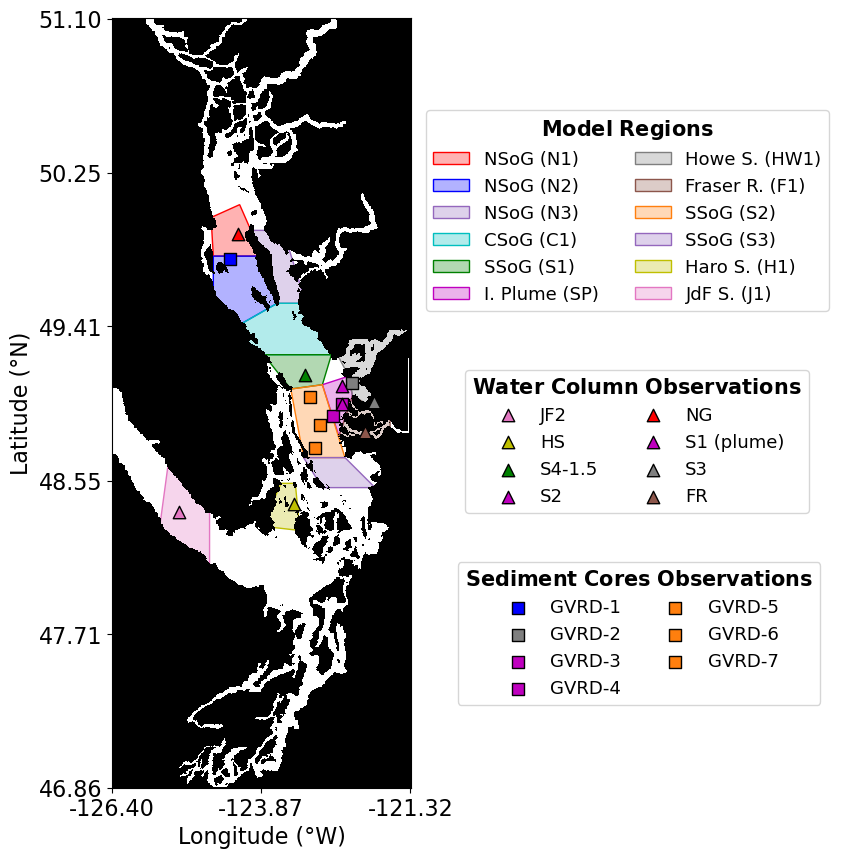

In [7]:
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
#
# --- Load data ---
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')

# --- Define colormap ---
colors = [(0, 0, 0, 1),  # Grey for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors)

plt.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(20,10)) 
gs = gridspec.GridSpec(1, 2, width_ratios=[2,1], figure=fig)

ax = fig.add_subplot(gs[0,0])   # top left
ax1 = fig.add_subplot(gs[0,1])   # bottom left
ax1.axis('off')
# --- Create coordinate arrays for pcolormesh ---
LON = np.linspace(mask['nav_lon'].min().values,
                  mask['nav_lon'].max().values,
                  len(mask.x))
LAT = np.linspace(mask['nav_lat'].min().values,
                  mask['nav_lat'].max().values,
                  len(mask.y))
longitudes, latitudes = np.meshgrid(LON, LAT)


# --- Regions ---
colors_regions = ['r', 'b', 'tab:purple', 'c', 'g', 'm', 'tab:gray', 'tab:brown', 'tab:orange', 'tab:purple', 'y', 'tab:pink']
regions = ['NSoG (N1)', 'NSoG (N2)', 'NSoG (N3)', 'CSoG (C1)', 'SSoG (S1)',
           'I. Plume (SP)', 'Howe S. (HW1)', 'Fraser R. (F1)', 'SSoG (S2)', 'SSoG (S3)', 'Haro S. (H1)', 'JdF S. (J1)']
#
plot_polygon(polygon_N1, ax = ax, color=colors_regions[0], label=regions[0],add_points=False)
plot_polygon(polygon_N2, ax = ax, color=colors_regions[1], label=regions[1],add_points=False)
plot_polygon(polygon_N3, ax = ax, color=colors_regions[2], label=regions[2],add_points=False)
plot_polygon(polygon_C1, ax = ax, color=colors_regions[3], label=regions[3],add_points=False)
plot_polygon(polygon_S1, ax = ax, color=colors_regions[4], label=regions[4],add_points=False)
plot_polygon(polygon_SP, ax = ax, color=colors_regions[5], label=regions[5],add_points=False)
plot_polygon(polygon_HW1, ax = ax, color=colors_regions[6], label=regions[6],add_points=False)
plot_polygon(polygon_F1, ax = ax, color=colors_regions[7], label=regions[7],add_points=False)
plot_polygon(polygon_S2, ax = ax, color=colors_regions[8], label=regions[8],add_points=False)
plot_polygon(polygon_S3, ax = ax, color=colors_regions[9], label=regions[9],add_points=False)
plot_polygon(polygon_H1, ax = ax, color=colors_regions[10], label=regions[10],add_points=False)
plot_polygon(polygon_J1, ax = ax, color=colors_regions[11], label=regions[11],add_points=False)


#
pcm = ax.pcolormesh(mask['tmask'][0, 0], cmap=cmap, shading='auto')

# --- Cores ("Grant et al., 2011") ---
color_cores = ['b', 'tab:gray', 'm', 'm', 'tab:orange', 'tab:orange', 'tab:orange']
scatter_cores = []
for i in range(len(lon_cores)):
    s = ax.scatter(x_obs_S[i], y_obs_S[i], marker='s', edgecolors='k',
                   c=color_cores[i], label=cores_labels[i], s=80)
    scatter_cores.append(s)

# --- Stations ("Sun et al., 2023") ---
color_stations = ['tab:pink', 'y', 'g', 'm', 'r', 'm', 'tab:gray', 'tab:brown']
scatter_stations = []
for i in range(len(lon)):
    s = ax.scatter(x_obs_WC[i], y_obs_WC[i], marker='^', edgecolors='k',
                   c=color_stations[i], label=stations[i], s=80)
    scatter_stations.append(s)

# --- Labels and aspect ---
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
ax.set_aspect(1.14)

# --- Set lon/lat ticks directly ---
n_xticks = 3
n_yticks = 6
xtick_positions = np.linspace(0, len(LON) - 1, n_xticks).astype(int)
ytick_positions = np.linspace(0, len(LAT) - 1, n_yticks).astype(int)

ax.set_xticks(xtick_positions)
ax.set_xticklabels([f"{LON[i]:.2f}" for i in xtick_positions])
ax.set_yticks(ytick_positions)
ax.set_yticklabels([f"{LAT[i]:.2f}" for i in ytick_positions])

ax.set_xlabel("Longitude (°W)")
ax.set_ylabel("Latitude (°N)")

# --- Legends stacked on the right ---
from matplotlib.legend import Legend

# 1️⃣ Model regions
handles_regions, labels_regions = ax.get_legend_handles_labels()
region_handles = handles_regions[:len(regions)]
region_labels = labels_regions[:len(regions)]
legend_model = Legend(ax, region_handles, region_labels, title=r"$\bf{Model}$ $\bf{Regions}$",
                      fontsize=13, title_fontsize=15, loc='center left', bbox_to_anchor=(1.02, .75), ncol = 2)

# 2️⃣ Sun et al. stations
legend_sun = Legend(ax, scatter_stations, stations, title=r"$\bf{Water}$ $\bf{Column}$ $\bf{Observations}$",
                    fontsize=13, title_fontsize=15, loc='center left', bbox_to_anchor=(1.15, 0.45), ncol = 2)

# 3️⃣ Grant et al. cores
legend_grant = Legend(ax, scatter_cores, cores_labels, title=r"$\bf{Sediment}$ $\bf{Cores}$ $\bf{Observations}$",
                      fontsize=13, title_fontsize=15, loc='center left', bbox_to_anchor=(1.125, 0.2), ncol = 2)

# Add all legends manually
legend_model.get_title().set_ha('center')
legend_sun.get_title().set_ha('center')
legend_grant.get_title().set_ha('center')

ax.add_artist(legend_model)
ax.add_artist(legend_sun)
ax.add_artist(legend_grant)

plt.subplots_adjust(right=0.55)  # leave 25% space on the right for legends
